<a href="https://colab.research.google.com/github/MaeSantos/CCDEPLRL/blob/main/Prodi_Santos_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog Emotion Classifier

---

## Project Information

| Field | Details |
|---|---|
| **Project Title** | Dog Emotion Classification using CNN |
| **Group Members** | Prodi, Santos |
| **Model Used** | Convolutional Neural Network (CNN) |

---

## Problem Description

Dogs communicate their emotions through facial expressions and body language, but it can be difficult for humans to accurately interpret these signals. This project builds a Convolutional Neural Network (CNN) that classifies a dog's emotion from an image into one of three categories: **Angry**, **Happy**, or **Sad**.

**Input:** Image of a dog  
**Output:** Predicted emotion label (Angry / Happy / Sad) with confidence score

---
# Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# Step 2 — Set Dataset Paths

The dataset is organized into **three separate splits** (train / val / test).

```
Dog_Emotions_Classification_Datasets/
├── train/
│   ├── Angry/
│   ├── Happy/
│   └── Sad/
├── val/
│   ├── Angry/
│   ├── Happy/
│   └── Sad/
└── test/
    ├── Angry/
    ├── Happy/
    └── Sad/
```


In [ ]:
import os

BASE_PATH  = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")

print("Train path:", TRAIN_PATH)
print("Val path  :", VAL_PATH)
print("Test path :", TEST_PATH)

Train path: /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/train
Val path  : /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/val
Test path : /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/test


### Auto-Split

In [ ]:
import shutil, random

SINGLE_FOLDER = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
OUTPUT_ROOT   = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
SPLITS        = {'train': 0.70, 'val': 0.15, 'test': 0.15}
CLASS_NAMES   = ['Angry', 'Happy', 'Sad']

random.seed(42)

for cls in CLASS_NAMES:
    src = os.path.join(SINGLE_FOLDER, cls)
    if not os.path.isdir(src):
        print(f"Skipping {cls} — folder not found at {src}")
        continue

    imgs   = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    random.shuffle(imgs)
    n      = len(imgs)
    n_tr   = int(n * SPLITS['train'])
    n_val  = int(n * SPLITS['val'])
    splits = {'train': imgs[:n_tr], 'val': imgs[n_tr:n_tr+n_val], 'test': imgs[n_tr+n_val:]}

    for split, files in splits.items():
        dst = os.path.join(OUTPUT_ROOT, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(src, f), os.path.join(dst, f))

    print(f"{cls}: {n_tr} train | {n_val} val | {len(splits['test'])} test")

print("\nDone! Update TRAIN_PATH / VAL_PATH / TEST_PATH above and re-run.")

Angry: 73 train | 15 val | 17 test
Happy: 73 train | 15 val | 17 test
Sad: 73 train | 15 val | 17 test

Done! Update TRAIN_PATH / VAL_PATH / TEST_PATH above and re-run.


---
# Step 3 — Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
# Step 4 — Verify Dataset Size

Confirm that each class has at least **100 images**

In [ ]:
CLASS_NAMES = ['Angry', 'Happy', 'Sad']
IMG_EXTS    = ('.jpg', '.jpeg', '.png', '.webp','.heic')

print(f"{'Split':<10} {'Class':<12} {'Count':>6}")
print("-" * 32)

totals = {}
for split, path in [('train', TRAIN_PATH), ('val', VAL_PATH), ('test', TEST_PATH)]:
    split_total = 0
    for cls in CLASS_NAMES:
        folder = os.path.join(path, cls)
        count  = len([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]) if os.path.isdir(folder) else 0
        split_total += count
        print(f"{split:<10} {cls:<12} {count:>6}")
    totals[split] = split_total
    print(f"{'':10} {'SUBTOTAL':<12} {split_total:>6}")
    print()

grand_total = sum(totals.values())
print(f"Grand total: {grand_total} images")
print("Meets 300 requirement" if 150 <= grand_total <= 300 else " Check image count requirements")

Split      Class         Count
--------------------------------
train      Angry            73
train      Happy            73
train      Sad              73
           SUBTOTAL        219

val        Angry            15
val        Happy            15
val        Sad              15
           SUBTOTAL         45

test       Angry            17
test       Happy            17
test       Sad              17
           SUBTOTAL         51

Grand total: 315 images
 Check image count requirements


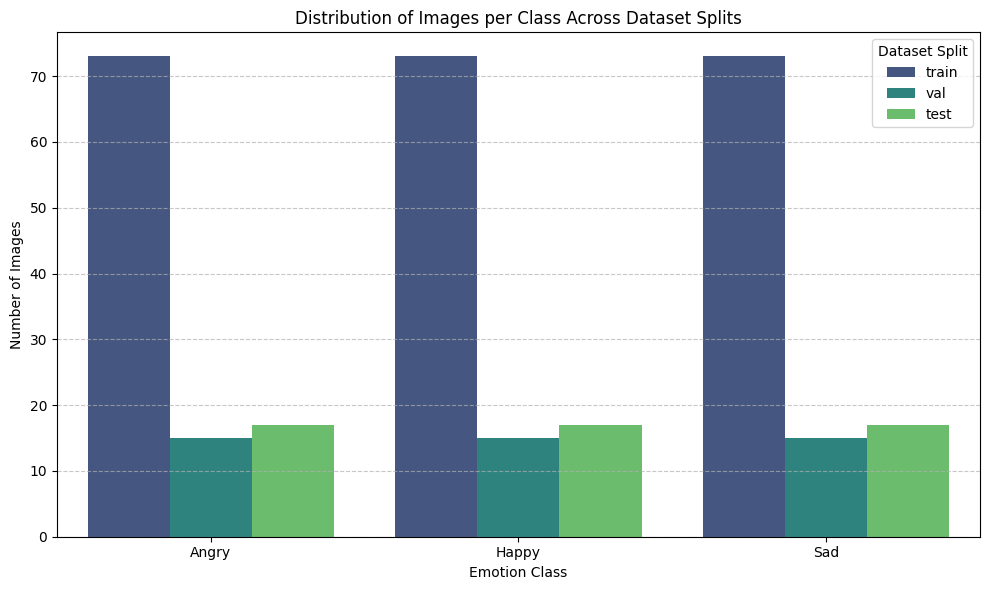

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data collection for plotting
plot_data = []
for split, path in [('train', TRAIN_PATH), ('val', VAL_PATH), ('test', TEST_PATH)]:
    for cls in CLASS_NAMES:
        folder = os.path.join(path, cls)
        count  = len([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]) if os.path.isdir(folder) else 0
        plot_data.append({'Split': split, 'Class': cls, 'Count': count})

df_plot = pd.DataFrame(plot_data)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', hue='Split', data=df_plot, palette='viridis')
plt.title('Distribution of Images per Class Across Dataset Splits')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Images')
plt.legend(title='Dataset Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
# Step 5 — Prepare Image Generators

- **Training:** with data augmentation (flips, zoom, rotation) to improve generalization
- **Validation & Test:** rescale only

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation and test generators — rescale only
val_test_datagen = ImageDataGenerator(rescale=1./255)

---
# Step 6 — Load Training, Validation, and Test Datasets

In [ ]:
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # keep order consistent for evaluation
)

NUM_CLASSES  = train_data.num_classes
CLASS_LABELS = list(train_data.class_indices.keys())

print(f"Classes      : {CLASS_LABELS}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Train batches: {len(train_data)}")
print(f"Val batches  : {len(val_data)}")
print(f"Test batches : {len(test_data)}")

Found 218 images belonging to 3 classes.
Found 44 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Classes      : ['Angry', 'Happy', 'Sad']
Num classes  : 3
Train batches: 7
Val batches  : 2
Test batches : 2


---
# Step 7 — Build CNN Model

Two Conv2D blocks for better feature extraction, plus Dropout to reduce overfitting.

In [ ]:
model = models.Sequential([

    # Block 1 — low-level feature detection (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — higher-level feature detection (shapes, patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — even higher-level feature detection
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),          # prevents overfitting
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

---
# Step 8 — Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

---
# Step 9 — Train Model

In [ ]:
EPOCHS = 50

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[early_stopping]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.3532 - loss: 1.3479 - val_accuracy: 0.4091 - val_loss: 1.0938
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3807 - loss: 1.0947 - val_accuracy: 0.3182 - val_loss: 1.0899
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3807 - loss: 1.0950 - val_accuracy: 0.4545 - val_loss: 1.0656
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.3945 - loss: 1.0871 - val_accuracy: 0.4318 - val_loss: 1.0603
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.4083 - loss: 1.0732 - val_accuracy: 0.5455 - val_loss: 1.0382
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4266 - loss: 1.0749 - val_accuracy: 0.5000 - val_loss: 1.0143
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.5138 - loss: 1.0201 - val_accuracy: 0.5455 - val_loss: 0.9887
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4908 - loss: 1.0241 - val_accuracy: 0.4545 - val_loss: 0.9872
Epoch 9/

---
# Step 10 — Evaluate Model

We evaluate on the **held-out test set**: data the model has never seen during training or validation.

In [ ]:
print("=" * 40)
print("Evaluation on Validation Set")
print("=" * 40)
val_loss, val_accuracy = model.evaluate(val_data, verbose=1)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

print()
print("=" * 40)
print("Evaluation on Test Set (Final)")
print("=" * 40)
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Evaluation on Validation Set
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.7955 - loss: 0.7898
Validation Loss    : 0.7898
Validation Accuracy: 79.55%

Evaluation on Test Set (Final)
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 849ms/step - accuracy: 0.5200 - loss: 1.2666
Test Loss    : 1.2666
Test Accuracy: 52.00%


---
# Step 11 — Plot Training Results

Visualize accuracy and loss over epochs to analyze model behavior.

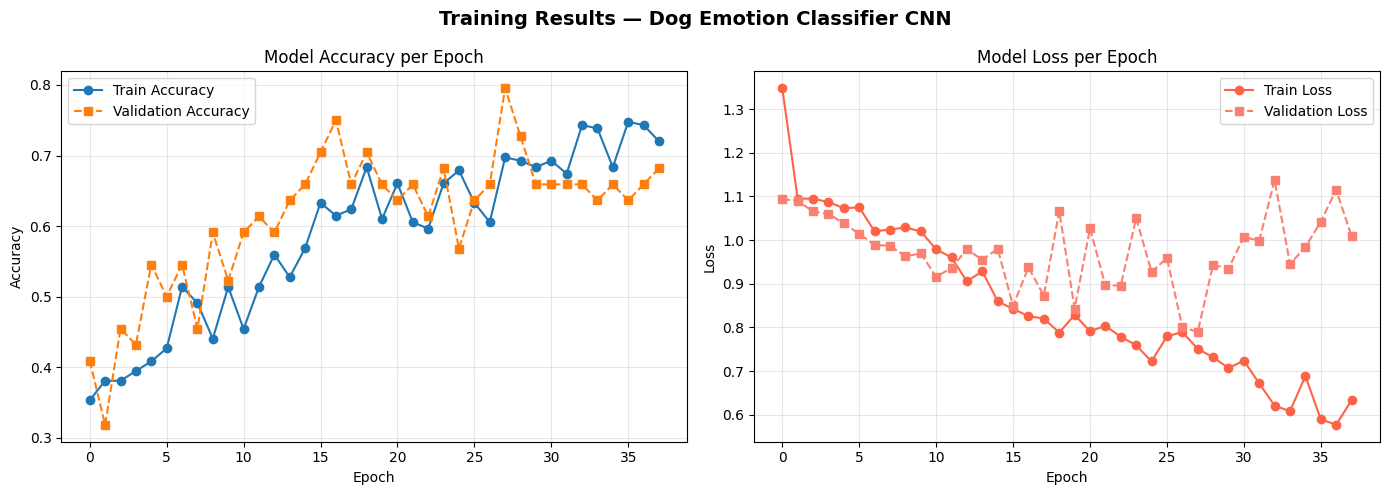

Final Training Accuracy  : 72.02%
Final Validation Accuracy: 68.18%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', linestyle='--')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      marker='o', color='tomato')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s', linestyle='--', color='salmon')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Results — Dog Emotion Classifier CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final Training Accuracy  : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

---
# Step 12 — Save Model

In [ ]:
model.save("cnn_classifier.h5")
print("Model saved as cnn_classifier.h5")

from google.colab import files
files.download("cnn_classifier.h5")
files.download("training_results.png")

Model saved as cnn_classifier.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Step 13 — Application Output (Demo)

Saving f31cad30-3a25-4773-8d5c-8ee1d34bf570.jpg to f31cad30-3a25-4773-8d5c-8ee1d34bf570.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


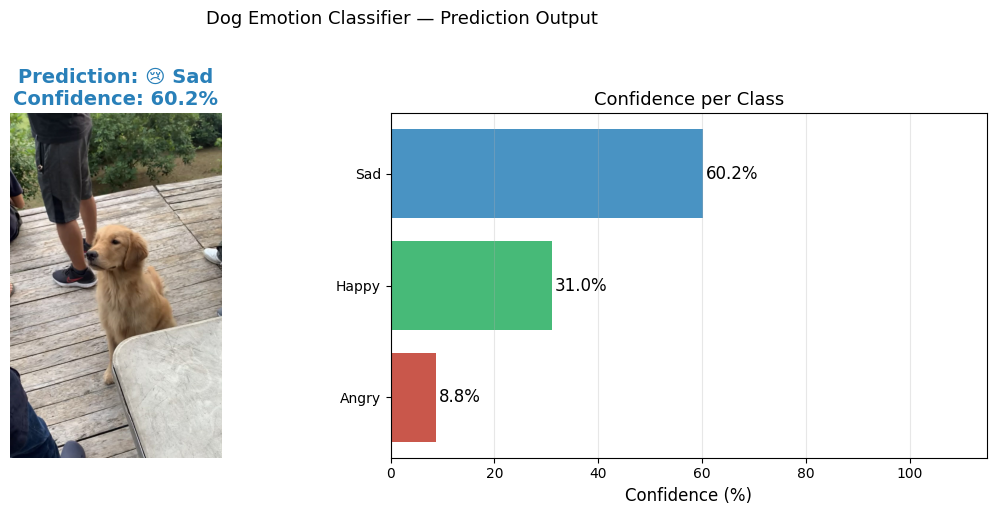


Predicted Emotion : Sad
Confidence        : 60.17%
  Angry   : ██                             8.8%
  Happy   : █████████                      31.0%
  Sad     : ██████████████████             60.2%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Preprocess
img       = keras_image.load_img(filename, target_size=(128, 128))
img_array = keras_image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions     = model.predict(img_array)[0]
predicted_idx   = np.argmax(predictions)
predicted_label = CLASS_LABELS[predicted_idx]
confidence      = predictions[predicted_idx] * 100

EMOJIS = {'Angry': '😠', 'Happy': '😄', 'Sad': '😢'}
COLORS = {'Angry': '#C0392B', 'Happy': '#27AE60', 'Sad': '#2980B9'}

# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left — image
ax1.imshow(keras_image.load_img(filename))
ax1.axis('off')
ax1.set_title(
    f"Prediction: {EMOJIS.get(predicted_label, '')} {predicted_label}\nConfidence: {confidence:.1f}%",
    fontsize=14, fontweight='bold', color=COLORS.get(predicted_label, 'black')
)

# Right — confidence bar chart
bar_colors  = [COLORS.get(c, '#888') for c in CLASS_LABELS]
bar_alphas  = [1.0 if c == predicted_label else 0.4 for c in CLASS_LABELS]
bars = ax2.barh(
    CLASS_LABELS,
    [p * 100 for p in predictions],
    color=bar_colors,
    alpha=0.85
)
for bar, pct in zip(bars, predictions):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct*100:.1f}%', va='center', fontsize=12)
ax2.set_xlim(0, 115)
ax2.set_xlabel('Confidence (%)', fontsize=12)
ax2.set_title('Confidence per Class', fontsize=13)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Dog Emotion Classifier — Prediction Output', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"Predicted Emotion : {predicted_label}")
print(f"Confidence        : {confidence:.2f}%")
print(f"{'='*40}")
for cls, prob in zip(CLASS_LABELS, predictions):
    bar = '█' * int(prob * 30)
    print(f"  {cls:<8}: {bar:<30} {prob*100:.1f}%")

---
# Step 14 — Deploy with Gradio (Public URL)


In [ ]:
!pip install gradio -q

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

EMOJIS = {'Angry': '😠', 'Happy': '😄', 'Sad': '😢'}

def classify_dog(img: Image.Image):
    img_resized = img.convert('RGB').resize((128, 128))
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds     = model.predict(arr, verbose=0)[0]
    top_idx   = int(np.argmax(preds))
    top_label = CLASS_LABELS[top_idx]

    scores = {
        f"{EMOJIS.get(cls, '')} {cls}": float(preds[i])
        for i, cls in enumerate(CLASS_LABELS)
    }
    summary = f"{EMOJIS.get(top_label, '')} {top_label} — {preds[top_idx]*100:.1f}% confidence"
    return summary, scores

with gr.Blocks(title="Dog Emotion Classifier", theme=gr.themes.Soft()) as demo:
    gr.Markdown("#Dog Emotion Classifier\nUpload a dog photo to predict its emotion (Angry / Happy / Sad).")
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type='pil', label='Upload Dog Image')
            submit_btn  = gr.Button('Classify Emotion', variant='primary')
        with gr.Column():
            result_text  = gr.Textbox(label='Predicted Emotion')
            result_chart = gr.Label(label='Confidence Scores', num_top_classes=3)
    submit_btn.click(fn=classify_dog, inputs=image_input, outputs=[result_text, result_chart])

demo.launch(share=True)

/tmp/ipykernel_7834/2406950280.py:26: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Dog Emotion Classifier", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a4050136ad4e72440.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
